In [1]:
import xarray as xr
import matplotlib.pyplot as plot
import os
import matplotlib.pyplot as plt

### Investigate Spatial Extent

In [32]:
goes_files = [f for f in os.listdir('./goes/') if f.endswith('.nc')]
goes_compressed = [f for f in os.listdir('./goes/compressed/') if f.endswith('.nc')]

In [16]:
goes_files

['20251030084020_AL132025_[+25.732deg_-73.344deg]_256_patch.nc',
 '20251030084020_AL132025_[+25.732deg_-73.344deg]_512_patch.nc',
 '20251030084020_AL132025_[+25.732deg_-73.344deg]_1024_patch.nc']

In [18]:
num = 0

print(goes_files[num])
ds_256 = xr.open_dataset('./goes/' + goes_files[num])
print(goes_files[num+1])
ds_512 = xr.open_dataset('./goes/' + goes_files[num+1])
print(goes_files[num+2])
ds_1024 = xr.open_dataset('./goes/' + goes_files[num+2])

20251030084020_AL132025_[+25.732deg_-73.344deg]_256_patch.nc
20251030084020_AL132025_[+25.732deg_-73.344deg]_512_patch.nc
20251030084020_AL132025_[+25.732deg_-73.344deg]_1024_patch.nc


In [20]:
ds_256.height

<xarray.DataArray 'height' (y: 256, x: 256)> Size: 262kB
[65536 values with dtype=float32]
Coordinates:
    t        datetime64[ns] 8B ...
  * y        (y) float32 1kB 0.08257 0.08252 0.08246 ... 0.0684 0.06835 0.06829
  * x        (x) float32 1kB -0.002604 -0.002548 -0.002492 ... 0.01162 0.01168
Attributes:
    long_name:            ABI L2+ Cloud Top Height
    standard_name:        geopotential_height_at_cloud_top
    valid_range:          [    0 65530]
    units:                m
    resolution:           y: 0.000056 rad x: 0.000056 rad
    grid_mapping:         goes_imager_projection
    cell_methods:         local_zenith_angle: point (good quality pixel produ...
    ancillary_variables:  DQF

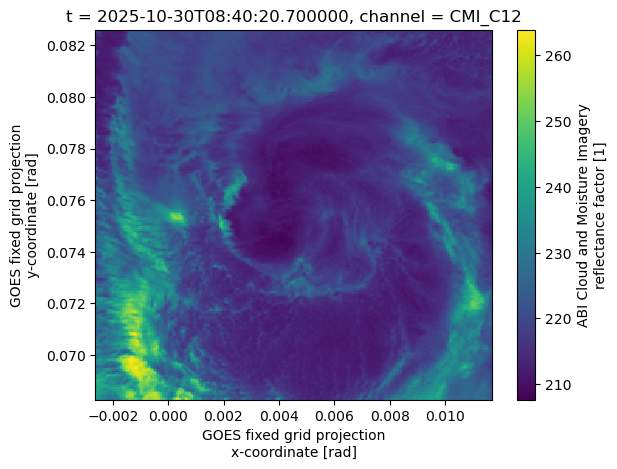

In [21]:
ds_256.data.isel(channel=11).plot()

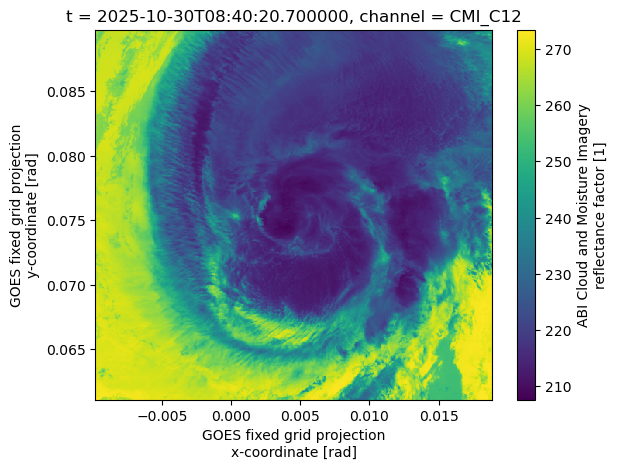

In [22]:
ds_512.data.isel(channel=11).plot()

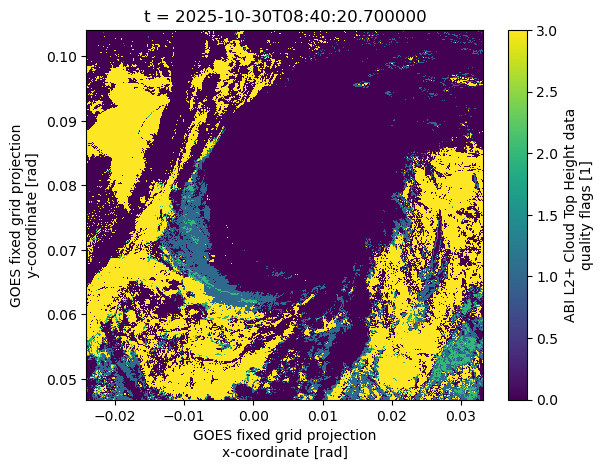

In [38]:
ds_1024.height_DQF.plot()

In [6]:
him_files = sorted([f for f in os.listdir('./himawari/') if f.endswith('.nc')])

In [27]:
print(him_files[1])
ds_him_256 = xr.open_dataset('./himawari/' + him_files[1])

print(him_files[2])
ds_him_512 = xr.open_dataset('./himawari/' + him_files[2])

print(him_files[0])
ds_him_1024 = xr.open_dataset('./himawari/' + him_files[0])

20250922023000_WP242025_[+19.295deg_+122.400deg]_256_patch.nc
20250922023000_WP242025_[+19.295deg_+122.400deg]_512_patch.nc
20250922023000_WP242025_[+19.295deg_+122.400deg]_1024_patch.nc


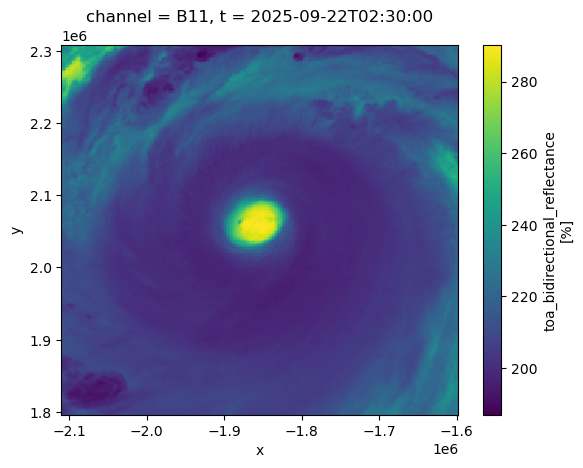

In [29]:
ds_him_256.data.isel(channel=10).plot()

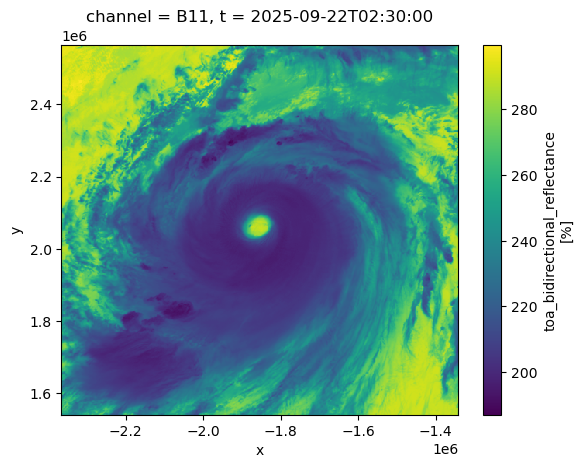

In [30]:
ds_him_512.data.isel(channel=10).plot()

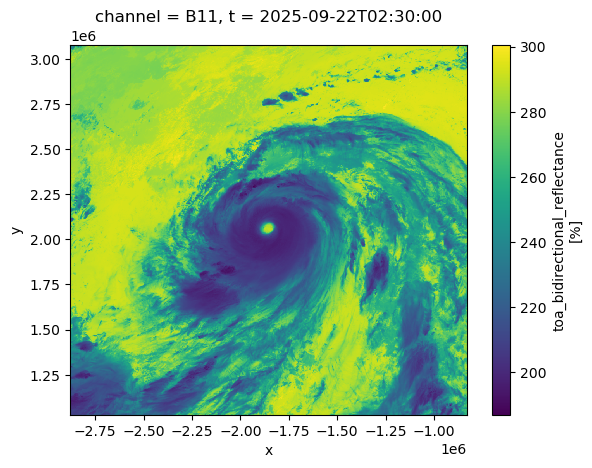

In [31]:
ds_him_1024.data.isel(channel=10).plot()

### Calculate Statistics 

##### Process

- Save 500 files at 512 x 512
- Calculate stats
- Add range to encoding
- Compare

Takeways
- The compression adds some floating point differences, but seems overall very good
- Add differences are very very small, and probably ok for our use cases

- The best approach for HIMAWARI however, seems to be to just reduce the range to what is in the attributes
- Otherwise, I noticed a couple of artifacts when the range was different

- For GOES, I am reducing the range a little bit, based on the calculated stats. These are now pretty much the same as for HIMAWARI. The reason was that the range for the GOES values is super high [0, 65530], so the compression doesn't work too well.

- Now, both satellites are compressed with largely the same range encodings


##### GOES

In [134]:
path = './goes-east/'
goes_files = os.listdir(path)

In [137]:
ds_test = xr.open_dataset(os.path.join(path, goes_files[1]))

In [139]:
ds_test.height

<xarray.DataArray 'height' (y: 512, x: 512)> Size: 1MB
[262144 values with dtype=float32]
Coordinates:
  * y        (y) float32 2kB 0.1181 0.118 0.118 ... 0.08957 0.08952 0.08946
  * x        (x) float32 2kB 0.07109 0.07115 0.0712 ... 0.0996 0.09965 0.09971
    t        datetime64[ns] 8B ...
Attributes:
    long_name:            ABI L2+ Cloud Top Height
    standard_name:        geopotential_height_at_cloud_top
    valid_range:          [    0 65530]
    units:                m
    resolution:           y: 0.000056 rad x: 0.000056 rad
    grid_mapping:         goes_imager_projection
    cell_methods:         local_zenith_angle: point (good quality pixel produ...
    ancillary_variables:  DQF

In [116]:
import numpy as np
import pandas as pd

stats_records = []
variables = ["height", "optical_depth", "particle_size", "temperature", "pressure"]

for file in sorted(goes_files):
    file_path = os.path.join(path, file)
    with xr.open_dataset(file_path) as ds:
        for var in variables:
            if var not in ds:
                continue

            values = np.asarray(ds[var].values).ravel()
            values = values[np.isfinite(values)]

            if values.size == 0:
                row = {
                    "file": file,
                    "variable": var,
                    "min": np.nan,
                    "max": np.nan,
                    "mean": np.nan,
                    "median": np.nan,
                }
            else:
                row = {
                    "file": file,
                    "variable": var,
                    "min": float(np.min(values)),
                    "max": float(np.max(values)),
                    "mean": float(np.mean(values)),
                    "median": float(np.median(values)),
                }

            stats_records.append(row)

stats_df = pd.DataFrame(stats_records)

# Easy access: stats_by_file_var.loc[("your_file.nc", "height")]
stats_by_file_var = stats_df.set_index(["file", "variable"]).sort_index()

stats_df.head()

,file,variable,min,max,mean,median
0,20230619205021_AL032023_[+11.197deg_-41.776deg...,height,0.000000,18552.722656,9493.510742,10983.976562
1,20230619205021_AL032023_[+11.197deg_-41.776deg...,optical_depth,0.000000,158.488647,3.810802,2.158401
2,20230619205021_AL032023_[+11.197deg_-41.776deg...,particle_size,0.000000,158.488647,45.835987,45.419201
3,20230619205021_AL032023_[+11.197deg_-41.776deg...,temperature,184.622009,303.981079,241.803101,233.386230
4,20230619205021_AL032023_[+11.197deg_-41.776deg...,pressure,72.247849,1013.954224,351.313293,250.802765


In [153]:
variable = 'particle_size'
stats_height = stats_by_file_var.xs(variable, level="variable")
print(stats_height['min'].min())
print(stats_height['max'].max())

0.0
158.4886474609375


In [164]:
variable = 'pressure_DQF'
ds_test[variable]

<xarray.DataArray 'pressure_DQF' (y: 512, x: 512)> Size: 262kB
[262144 values with dtype=int8]
Coordinates:
  * y        (y) float32 2kB 0.1181 0.118 0.118 ... 0.08957 0.08952 0.08946
  * x        (x) float32 2kB 0.07109 0.07115 0.0712 ... 0.0996 0.09965 0.09971
    t        datetime64[ns] 8B ...
Attributes: (12/14)
    long_name:                       ABI L2+ Cloud Top Pressure data quality ...
    standard_name:                   status_flag
    valid_range:                     [0 3]
    units:                           1
    flag_values:                     [0 1 2 3 4]
    flag_meanings:                   good_quality_qf marginal_quality_qf retr...
    ...                              ...
    cell_methods:                    local_zenith_angle: point solar_zenith_a...
    percent_good_quality_qf:         0.652711
    percent_marginal_quality_qf:     0.022253525
    percent_retrieval_attempted_qf:  0.0022718543
    percent_bad_quality_qf:          0.33377582
    percent_opaque_retrieval_qf:     0.0

In [213]:
without_comp = xr.open_dataset('./goes-east/20240618230021_AL012024_[+22.273deg_-92.723deg]_512_patch.nc')
with_comp = xr.open_dataset('./goes-east/compressed-512/AL012024/20240618230021_AL012024_[+22.273deg_-92.723deg]_512_patch.nc')

In [214]:
without_comp.optical_depth

<xarray.DataArray 'optical_depth' (y: 512, x: 512)> Size: 1MB
[262144 values with dtype=float32]
Coordinates:
  * y        (y) float32 2kB 0.07994 0.07988 0.07983 ... 0.05144 0.05138 0.05132
  * x        (x) float32 2kB -0.06336 -0.06331 -0.06325 ... -0.0348 -0.03475
    t        datetime64[ns] 8B ...
Attributes:
    long_name:            ABI L2+ Cloud Optical Depth at 640 nm
    standard_name:        atmosphere_optical_thickness_due_to_cloud
    valid_range:          [    0 65530]
    units:                1
    resolution:           y: 0.000056 rad x: 0.000056 rad
    grid_mapping:         goes_imager_projection
    cell_methods:         day_retrieval_local_zenith_angle: point (good or de...
    ancillary_variables:  DQF

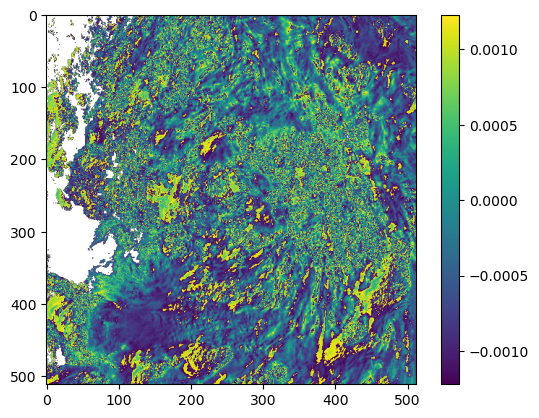

In [220]:
variable = 'particle_size'
plt.imshow(without_comp[variable].values - with_comp[variable].values)
plt.colorbar()

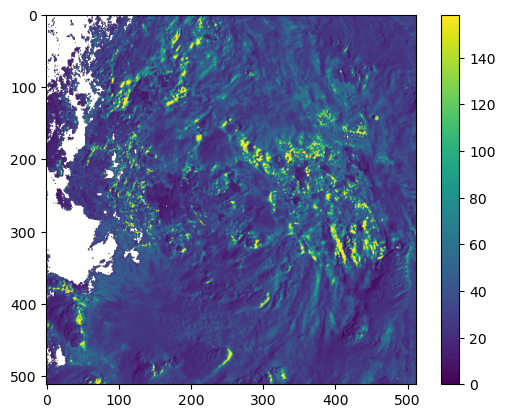

In [221]:
variable = 'particle_size'
plt.imshow(without_comp[variable].values)
plt.colorbar()

##### HIMAWARI

In [127]:
path = './himawari/'
him_files = os.listdir(path)

In [128]:
ds_test = xr.open_dataset(os.path.join(path, him_files[0]))

In [129]:
ds_test

<xarray.Dataset> Size: 47MB
Dimensions:        (channel: 16, y: 512, x: 512, angle: 2)
Coordinates:
  * channel        (channel) <U3 192B 'B01' 'B02' 'B03' ... 'B14' 'B15' 'B16'
  * y              (y) float64 4kB 4.201e+06 4.199e+06 ... 3.181e+06 3.179e+06
  * x              (x) float64 4kB -1.63e+05 -1.61e+05 ... 8.57e+05 8.59e+05
    t              datetime64[ns] 8B ...
Dimensions without coordinates: angle
Data variables: (12/16)
    data           (channel, y, x) float64 34MB ...
    latitude       (y, x) float32 1MB ...
    longitude      (y, x) float32 1MB ...
    sat_angle      (angle, y, x) float32 2MB ...
    solar_angle    (angle, y, x) float32 2MB ...
    height         (y, x) float32 1MB ...
    ...             ...
    mask_DQF       (y, x) int8 262kB ...
    temperature    (y, x) float32 1MB ...
    phase          (y, x) float32 1MB ...
    phase_DQF      (y, x) int8 262kB ...
    pressure       (y, x) float32 1MB ...
    type           (y, x) int8 262kB ...
Attributes:
    history:      Created by pytroll/satpy on 2026-06-24 19:03:26.168357+00:00
    Conventions:  CF-1.7

In [15]:
import numpy as np
import pandas as pd

stats_records = []
variables = ["height", "optical_depth", "temperature", "pressure"]

for file in sorted(him_files):
    file_path = os.path.join(path, file)
    with xr.open_dataset(file_path) as ds:
        for var in variables:
            if var not in ds:
                continue

            values = np.asarray(ds[var].values).ravel()
            values = values[np.isfinite(values)]

            if values.size == 0:
                row = {
                    "file": file,
                    "variable": var,
                    "min": np.nan,
                    "max": np.nan,
                    "mean": np.nan,
                    "median": np.nan,
                }
            else:
                row = {
                    "file": file,
                    "variable": var,
                    "min": float(np.min(values)),
                    "max": float(np.max(values)),
                    "mean": float(np.mean(values)),
                    "median": float(np.median(values)),
                }

            stats_records.append(row)

stats_df = pd.DataFrame(stats_records)

# Easy access: stats_by_file_var.loc[("your_file.nc", "height")]
stats_by_file_var = stats_df.set_index(["file", "variable"]).sort_index()

stats_df.head()

,file,variable,min,max,mean,median
0,20230817002000_WP072023_[+44.074deg_+138.448de...,height,0.000000,16829.945312,6550.264648,7207.710938
1,20230817002000_WP072023_[+44.074deg_+138.448de...,optical_depth,0.000000,20.000000,1.742395,1.998308
2,20230817002000_WP072023_[+44.074deg_+138.448de...,temperature,181.429245,307.602386,260.937592,259.881622
3,20230817002000_WP072023_[+44.074deg_+138.448de...,pressure,99.798080,1010.246338,503.578796,415.932648
4,20230821184000_WP082023_[+19.026deg_+153.758de...,height,0.000000,16500.712891,9488.618164,10792.429688


In [60]:
variable = 'temperature'
stats_height = stats_by_file_var.xs(variable, level="variable")
print(stats_height['min'].min())
print(stats_height['max'].max())

170.0
320.0


In [ ]:
# load example compressed file
without_comp = xr.open_dataset("./himawari/20240405191000_SH212024_[-12.530deg_+120.034deg]_512_patch.nc")
with_comp = xr.open_dataset("./himawari/compressed/20240405191000_SH212024_[-12.530deg_+120.034deg]_512_patch.nc")

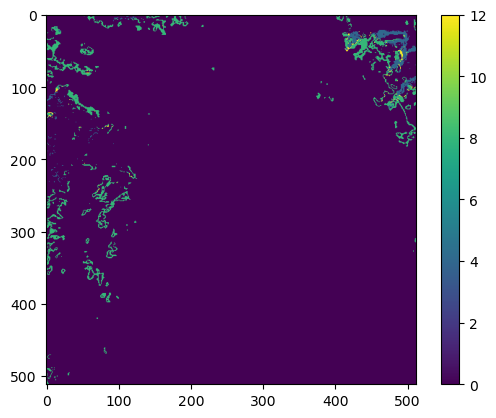

In [104]:
variable = 'phase_DQF'
plt.imshow(without_comp[variable].values - with_comp[variable].values)
plt.colorbar()

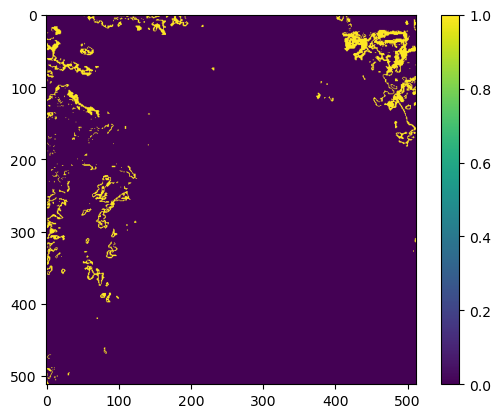

In [106]:
plt.imshow(with_comp[variable].values)
plt.colorbar()